In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from time import perf_counter
import os

In [45]:
# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)

# Download Fashion MNIST from Kaggle
print("Downloading Fashion MNIST dataset...")
path = kagglehub.dataset_download("zalando-research/fashionmnist")
print(f"Dataset downloaded to: {path}")

Dataset downloaded to: /Users/andreaigner/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4


In [46]:
train_data = pd.read_csv(os.path.join(path, 'fashion-mnist_train.csv'))
print(f"Training data shape: {train_data.shape}")
print(train_data.head())

Training data shape: (60000, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      2       0       0       0       0       0       0       0       0   
1      9       0       0       0       0       0       0       0       0   
2      6       0       0       0       0       0       0       0       5   
3      0       0       0       0       1       2       0       0       0   
4      3       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0        30        43         0   
3       0  ...         3         0         0         0         0         1   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel78

In [47]:
X_features = train_data.drop('label', axis=1)
y = train_data['label']
print(f"Label: {y}")

Label: 0        2
1        9
2        6
3        0
4        3
        ..
59995    9
59996    1
59997    8
59998    8
59999    7
Name: label, Length: 60000, dtype: int64


In [48]:
scaler = StandardScaler()
X = scaler.fit_transform(X_features)
X_scaler = X

In [ ]:
pca = PCA(n_components=2)
standard_pca_start_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
standard_pca_start = perf_counter()
print(f"[{standard_pca_start_ts}] Starting standard PCA fit_transform...")
X = pca.fit_transform(X)
standard_pca_duration = perf_counter() - standard_pca_start
standard_pca_end_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"[{standard_pca_end_ts}] Completed standard PCA fit_transform.")
print(f"Standard PCA duration: {standard_pca_duration:.2f} seconds")
print(X.shape)

[2025-11-11 14:20:15] Starting standard PCA fit_transform...
[2025-11-11 14:20:15] Completed standard PCA fit_transform.
Standard PCA duration: 0.18 seconds
(60000, 2)


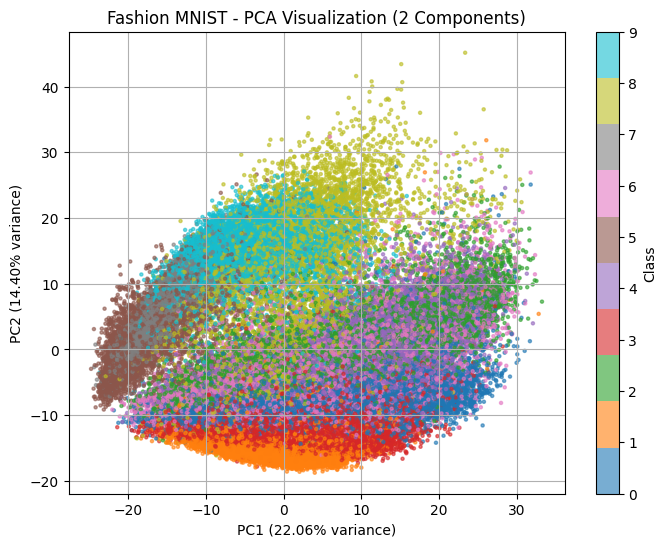

(60000, 2)


In [50]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], 
                     c=y, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Fashion MNIST - PCA Visualization (2 Components)')
plt.grid(True)
plt.show()
print(X.shape)

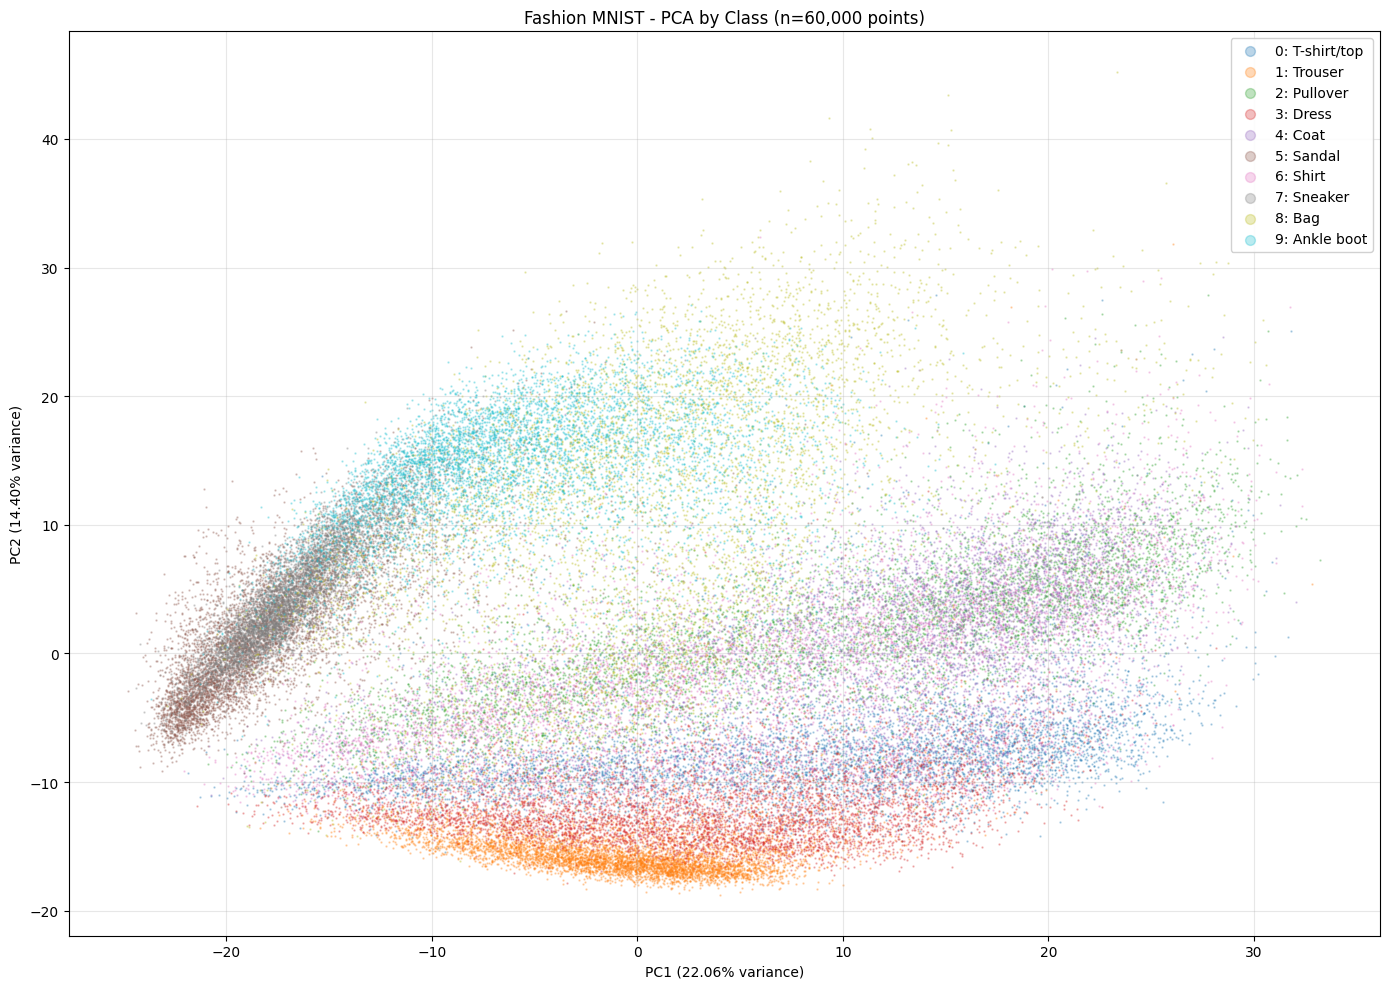


Total points plotted: 60000
Points per class:
  0: T-shirt/top: 6000
  1: Trouser: 6000
  2: Pullover: 6000
  3: Dress: 6000
  4: Coat: 6000
  5: Sandal: 6000
  6: Shirt: 6000
  7: Sneaker: 6000
  8: Bag: 6000
  9: Ankle boot: 6000


In [51]:
plt.figure(figsize=(14, 10))
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot all points with smaller size and lower alpha
for i, class_name in enumerate(class_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], 
               label=f'{i}: {class_name}', alpha=0.3, s=0.5, rasterized=True)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'Fashion MNIST - PCA by Class (n={len(X):,} points)')
plt.legend(markerscale=10, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print stats to verify all points are included
print(f"\nTotal points plotted: {len(X)}")
print(f"Points per class:")
for i, class_name in enumerate(class_names):
    count = (y == i).sum()
    print(f"  {i}: {class_name}: {count}")

## Randomized PCA Comparison

We contrast the deterministic full SVD PCA with its randomized SVD variant to verify that the faster approximation preserves the structure of the Fashion MNIST embedding.


[2025-11-11 14:20:16] Starting randomized PCA fit_transform...
[2025-11-11 14:20:16] Completed randomized PCA fit_transform.
Randomized PCA duration: 0.31 seconds


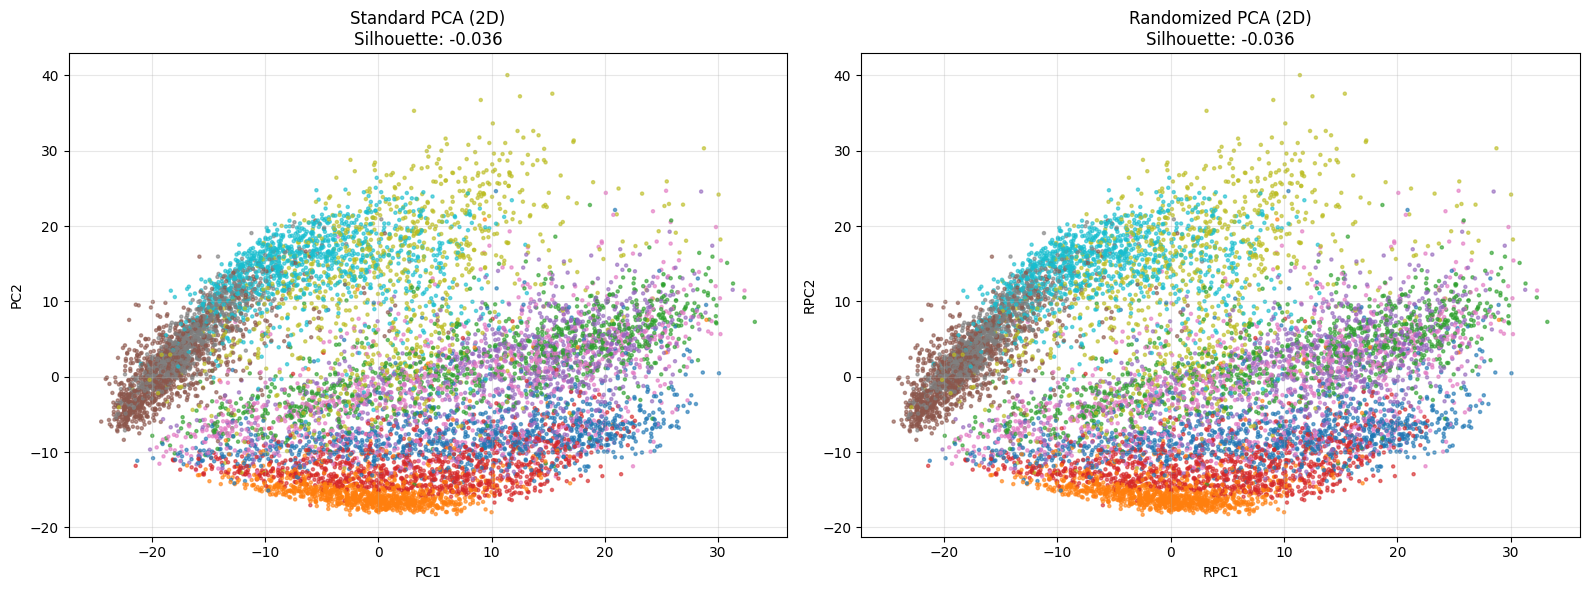

Explained variance ratio (2 components):
  Standard PCA   : [0.22057176 0.14395563]
  Randomized PCA : [0.22057176 0.14395563]
Runtime comparison:
  Standard PCA duration   : 0.18 seconds
  Randomized PCA duration : 0.31 seconds
Quantitative comparison on 10000 samples:
  Standard PCA silhouette   : -0.0364
  Randomized PCA silhouette : -0.0364


In [52]:
from sklearn.metrics import silhouette_score

pca_rand = PCA(n_components=2, svd_solver='randomized', random_state=42)
randomized_pca_start_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
randomized_pca_start = perf_counter()
print(f"[{randomized_pca_start_ts}] Starting randomized PCA fit_transform...")
X_rand = pca_rand.fit_transform(X_scaler)
rand_pca_duration = perf_counter() - randomized_pca_start
randomized_pca_end_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"[{randomized_pca_end_ts}] Completed randomized PCA fit_transform.")
print(f"Randomized PCA duration: {rand_pca_duration:.2f} seconds")

rng = np.random.default_rng(42)
sample_size = min(10000, X.shape[0])
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)

X_pca_sample = X[sample_idx]
X_rand_sample = X_rand[sample_idx]
labels_sample = y.iloc[sample_idx].to_numpy()

pca_silhouette = silhouette_score(X_pca_sample, labels_sample)
rand_silhouette = silhouette_score(X_rand_sample, labels_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False, sharey=False)

axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                c=labels_sample, cmap='tab10', alpha=0.6, s=5)
axes[0].set_title(f'Standard PCA (2D)\nSilhouette: {pca_silhouette:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_rand_sample[:, 0], X_rand_sample[:, 1],
                c=labels_sample, cmap='tab10', alpha=0.6, s=5)
axes[1].set_title(f'Randomized PCA (2D)\nSilhouette: {rand_silhouette:.3f}')
axes[1].set_xlabel('RPC1')
axes[1].set_ylabel('RPC2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Explained variance ratio (2 components):")
print(f"  Standard PCA   : {pca.explained_variance_ratio_[:2]}")
print(f"  Randomized PCA : {pca_rand.explained_variance_ratio_[:2]}")
print("Runtime comparison:")
print(f"  Standard PCA duration   : {standard_pca_duration:.2f} seconds")
print(f"  Randomized PCA duration : {rand_pca_duration:.2f} seconds")
print(f"Quantitative comparison on {sample_size} samples:")
print(f"  Standard PCA silhouette   : {pca_silhouette:.4f}")
print(f"  Randomized PCA silhouette : {rand_silhouette:.4f}")


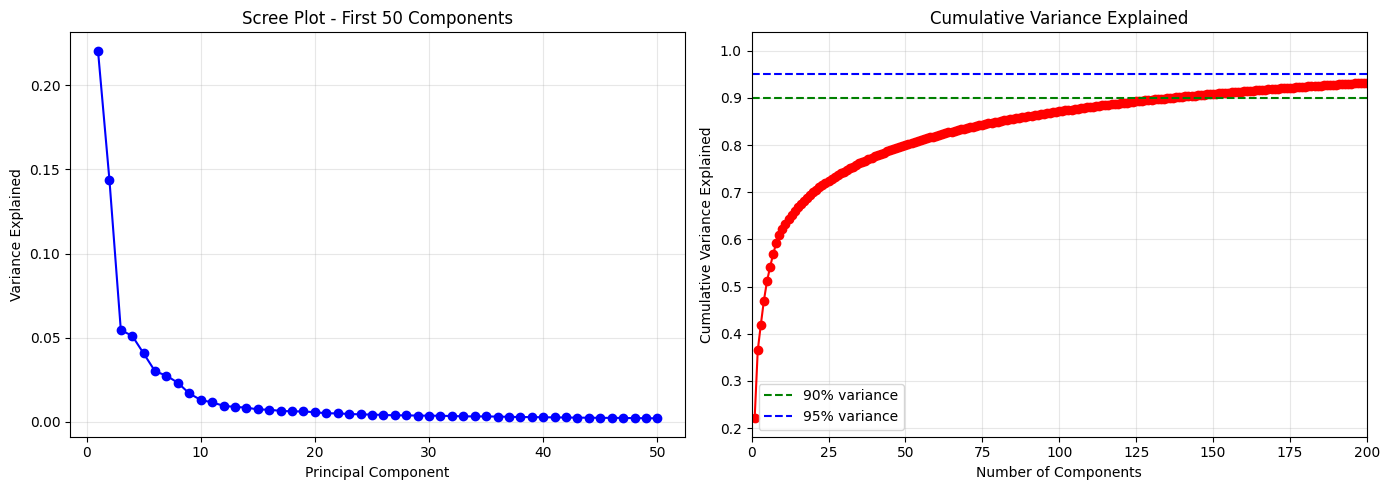

Components for 90% variance: 137
Components for 95% variance: 256


In [ ]:
# 1. Analyze variance explained - how many components do we really need?
pca_full = PCA()
pca_full.fit(X_scaler)

plt.figure(figsize=(14, 5))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, 51), pca_full.explained_variance_ratio_[:50], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot - First 50 Components')
plt.grid(True, alpha=0.3)

# Cumulative variance
plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum)+1), cumsum, 'ro-')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

# How many components needed?
n_90 = np.argmax(cumsum >= 0.90) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")

## Independent Component Analysis (ICA)

We now apply Independent Component Analysis to separate statistically independent sources in the Fashion MNIST pixel space and compare the 2D embedding to the PCA visualization.


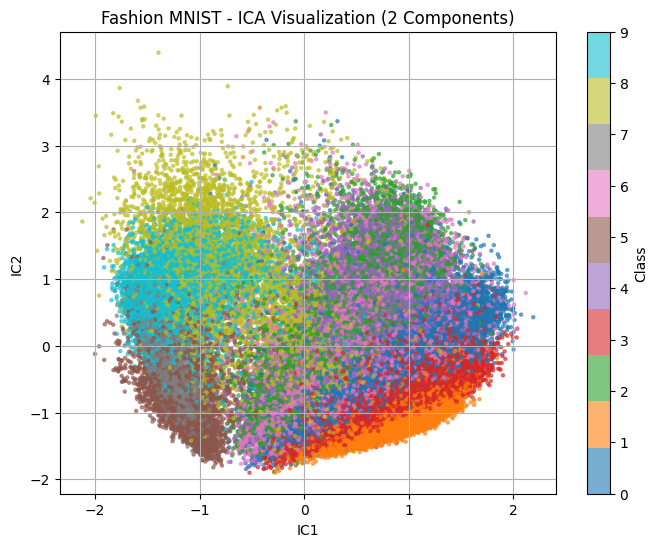

ICA components shape: (60000, 2)
Mixing matrix (first two rows):
[[ 0.00191898  0.00412205]
 [-0.00111492  0.01924618]]


In [ ]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components=2, random_state=42, whiten='unit-variance')
X_ica = ica.fit_transform(X_scaler)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_ica[:, 0], X_ica[:, 1],
                     c=y, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.xlabel('IC1')
plt.ylabel('IC2')
plt.title('Fashion MNIST - ICA Visualization (2 Components)')
plt.grid(True)
plt.show()

print(f"ICA components shape: {X_ica.shape}")
print("Mixing matrix (first two rows):")
print(ica.mixing_[:2])


### PCA vs. ICA Comparison

To compare both 2D embeddings, we visualize them side by side and quantify class separation with the silhouette score (using a 10k sample for efficiency).


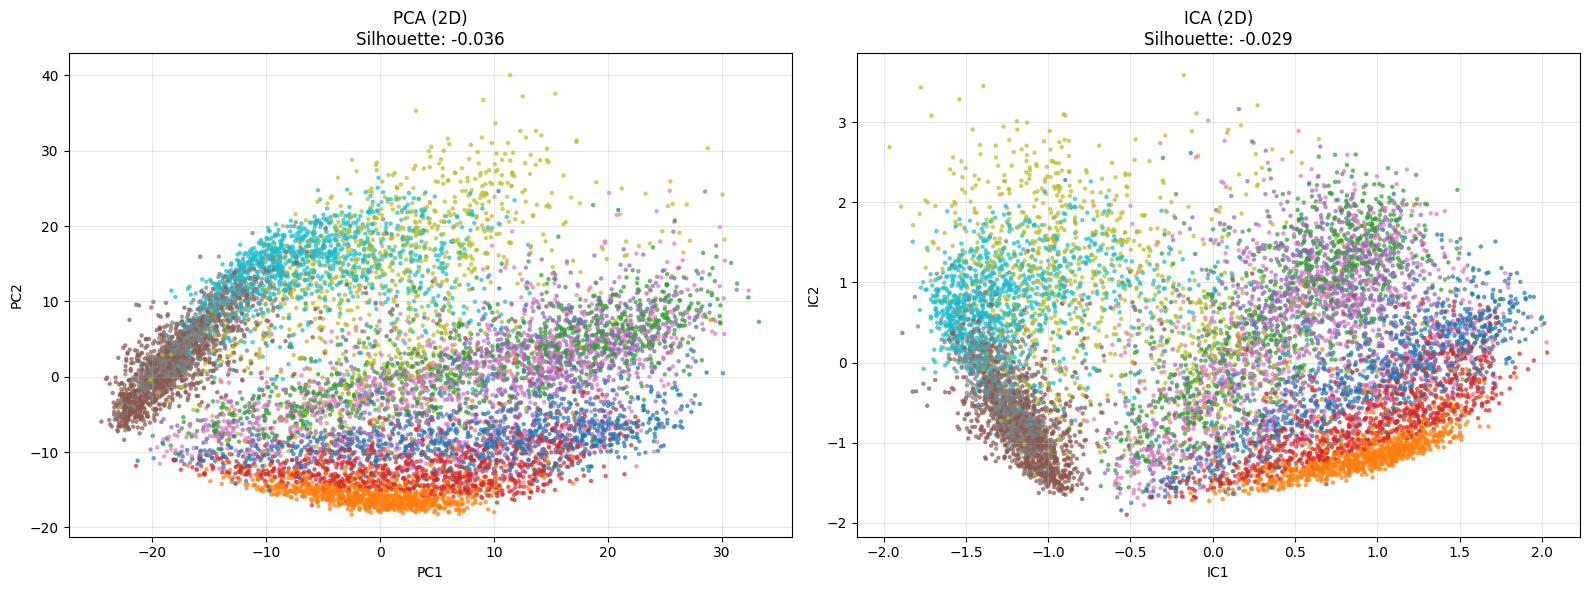

Quantitative comparison (10k sample):
  PCA silhouette score : -0.0364
  ICA silhouette score : -0.0291


In [ ]:
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(42)
sample_size = min(10000, X.shape[0])
sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)

X_pca_sample = X[sample_idx]
X_ica_sample = X_ica[sample_idx]
labels_sample = y.iloc[sample_idx].to_numpy()

pca_silhouette = silhouette_score(X_pca_sample, labels_sample)
ica_silhouette = silhouette_score(X_ica_sample, labels_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False, sharey=False)

axes[0].scatter(X_pca_sample[:, 0], X_pca_sample[:, 1],
                c=labels_sample, cmap='tab10', alpha=0.6, s=5)
axes[0].set_title(f'PCA (2D)\nSilhouette: {pca_silhouette:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_ica_sample[:, 0], X_ica_sample[:, 1],
                c=labels_sample, cmap='tab10', alpha=0.6, s=5)
axes[1].set_title(f'ICA (2D)\nSilhouette: {ica_silhouette:.3f}')
axes[1].set_xlabel('IC1')
axes[1].set_ylabel('IC2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Quantitative comparison (10k sample):")
print(f"  PCA silhouette score : {pca_silhouette:.4f}")
print(f"  ICA silhouette score : {ica_silhouette:.4f}")


### 3D Interactive PCA & ICA

Install Plotly first (e.g. `pip install plotly`) to enable the interactive 3D visuals below.


In [ ]:
import plotly.express as px

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaler)

ica_3d = FastICA(n_components=3, random_state=42, whiten='unit-variance')
X_ica_3d = ica_3d.fit_transform(X_scaler)

rng3d = np.random.default_rng(123)
sample_size_3d = min(5000, X_scaler.shape[0])
sample_idx_3d = rng3d.choice(X_scaler.shape[0], size=sample_size_3d, replace=False)

labels_sample_3d = y.iloc[sample_idx_3d].to_numpy()
class_map = {i: name for i, name in enumerate(class_names)}
class_names_sample = [class_map[int(lbl)] for lbl in labels_sample_3d]

pca_df = pd.DataFrame({
    'PC1': X_pca_3d[sample_idx_3d, 0],
    'PC2': X_pca_3d[sample_idx_3d, 1],
    'PC3': X_pca_3d[sample_idx_3d, 2],
    'label': labels_sample_3d,
    'Class': class_names_sample,
})

ica_df = pd.DataFrame({
    'IC1': X_ica_3d[sample_idx_3d, 0],
    'IC2': X_ica_3d[sample_idx_3d, 1],
    'IC3': X_ica_3d[sample_idx_3d, 2],
    'label': labels_sample_3d,
    'Class': class_names_sample,
})

fig_pca_3d = px.scatter_3d(
    pca_df,
    x='PC1', y='PC2', z='PC3',
    color='Class',
    hover_data={'label': True, 'Class': True},
    title='Fashion MNIST - PCA (3 Components)'
)
fig_pca_3d.update_traces(marker=dict(size=3, opacity=0.6))
fig_pca_3d.update_layout(legend_title_text='Class')
fig_pca_3d.show()

fig_ica_3d = px.scatter_3d(
    ica_df,
    x='IC1', y='IC2', z='IC3',
    color='Class',
    hover_data={'label': True, 'Class': True},
    title='Fashion MNIST - ICA (3 Components)'
)
fig_ica_3d.update_traces(marker=dict(size=3, opacity=0.6))
fig_ica_3d.update_layout(legend_title_text='Class')
fig_ica_3d.show()


In [57]:
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE
from plotly.subplots import make_subplots
import plotly.graph_objects as go

X_sample_3d = X_scaler[sample_idx_3d]

kpca_rbf = KernelPCA(n_components=3, kernel='rbf', gamma=1e-3)
X_kpca_3d = kpca_rbf.fit_transform(X_sample_3d)

tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42,
)
X_tsne_3d = tsne_3d.fit_transform(X_sample_3d)

embeddings = [
    ("PCA (3 Components)", X_pca_3d[sample_idx_3d]),
    ("ICA (3 Components)", X_ica_3d[sample_idx_3d]),
    ("Kernel PCA (RBF)", X_kpca_3d),
    ("t-SNE", X_tsne_3d),
]

fig_compare = make_subplots(
    rows=2,
    cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}],
           [{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=[title for title, _ in embeddings]
)

for idx, (title, values) in enumerate(embeddings):
    embedding_df = pd.DataFrame({
        'Dim1': values[:, 0],
        'Dim2': values[:, 1],
        'Dim3': values[:, 2],
        'label': labels_sample_3d,
        'Class': class_names_sample,
    })
    scatter_fig = px.scatter_3d(
        embedding_df,
        x='Dim1',
        y='Dim2',
        z='Dim3',
        color='Class',
        hover_data={'label': True, 'Class': True},
    )
    row = idx // 2 + 1
    col = idx % 2 + 1
    for trace in scatter_fig.data:
        if idx > 0:
            trace.showlegend = False
        fig_compare.add_trace(trace, row=row, col=col)

scene_names = ['scene', 'scene2', 'scene3', 'scene4']
for scene in scene_names:
    fig_compare.layout[scene].xaxis.title = 'Component 1'
    fig_compare.layout[scene].yaxis.title = 'Component 2'
    fig_compare.layout[scene].zaxis.title = 'Component 3'

fig_compare.update_layout(
    height=900,
    width=1100,
    title_text=f'3D Embedding Comparison on {sample_size_3d} Samples',
    legend=dict(title='Class', itemsizing='constant')
)

fig_compare.show()


In [58]:
kpca_rbf_2d = KernelPCA(n_components=2, kernel='rbf', gamma=1e-3)
X_kpca_2d = kpca_rbf_2d.fit_transform(X_sample_3d)

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42,
)
X_tsne_2d = tsne_2d.fit_transform(X_sample_3d)

embeddings_2d = [
    ("PCA (2 Components)", X[sample_idx_3d]),
    ("ICA (2 Components)", X_ica[sample_idx_3d]),
    ("Kernel PCA (RBF, 2D)", X_kpca_2d),
    ("t-SNE (2D)", X_tsne_2d),
]

fig_compare_2d = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[title for title, _ in embeddings_2d],
    horizontal_spacing=0.08,
    vertical_spacing=0.12,
)

for idx, (title, values) in enumerate(embeddings_2d):
    embedding_df = pd.DataFrame({
        'Dim1': values[:, 0],
        'Dim2': values[:, 1],
        'label': labels_sample_3d,
        'Class': class_names_sample,
    })
    scatter_fig = px.scatter(
        embedding_df,
        x='Dim1',
        y='Dim2',
        color='Class',
        hover_data={'label': True, 'Class': True},
    )
    row = idx // 2 + 1
    col = idx % 2 + 1
    for trace in scatter_fig.data:
        if idx > 0:
            trace.showlegend = False
        fig_compare_2d.add_trace(trace, row=row, col=col)
    fig_compare_2d.update_xaxes(title_text='Component 1', row=row, col=col)
    fig_compare_2d.update_yaxes(title_text='Component 2', row=row, col=col)

fig_compare_2d.update_layout(
    height=800,
    width=1100,
    title_text=f'2D Embedding Comparison on {sample_size_3d} Samples',
    legend=dict(title='Class', itemsizing='constant')
)

fig_compare_2d.show()


In [59]:
tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42,
)
X_tsne_3d = tsne_3d.fit_transform(X_sample_3d)

tsne_3d_df = pd.DataFrame({
    'Dim1': X_tsne_3d[:, 0],
    'Dim2': X_tsne_3d[:, 1],
    'Dim3': X_tsne_3d[:, 2],
    'label': labels_sample_3d,
    'Class': class_names_sample,
})

fig_tsne_3d = px.scatter_3d(
    tsne_3d_df,
    x='Dim1',
    y='Dim2',
    z='Dim3',
    color='Class',
    hover_data={'label': True, 'Class': True},
)
fig_tsne_3d.update_layout(
    height=700,
    width=900,
    title=f't-SNE (3D) on {sample_size_3d} Samples',
    legend=dict(title='Class', itemsizing='constant')
)
fig_tsne_3d.show()

